## FEATURE ENGINEERING AND FITTING

In [179]:
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score

In [180]:
#!ls -l china-real-estate-demand-prediction/train

In [181]:
def month_sect_conv(df: pd.DataFrame) -> pd.DataFrame:
    """
    This function takes a Pandas DataFrame, to divide month and year and convert sectors to integers dtype
    """
    if 'month' in df.columns:
        df["ts"] = pd.to_datetime(df['month'], format='%Y-%b')
        df["month"] = df["ts"].dt.month
        df["year"] = df["ts"].dt.year        
        df.drop('ts', axis=1, inplace=True)
        
    if 'sector' in df.columns:
        df['sector'] = df['sector'].str.replace('sector ', '')
        df['sector'] = df['sector'].astype(int)

    return df


def change_indx_to_zero(df: pd.DataFrame, col_name='time_index') -> pd.DataFrame:
    X2 = df.pop(col_name)
    df.insert(0, col_name, X2)

    return df

In [182]:
#Loading all the train data

city_indexes = pd.read_csv('china-real-estate-demand-prediction/train/city_indexes.csv')
city_search_index = pd.read_csv('china-real-estate-demand-prediction/train/city_search_index.csv')

land_transactions = pd.read_csv('china-real-estate-demand-prediction/train/land_transactions.csv')
land_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/land_transactions_nearby_sectors.csv')

new_house_transactions = pd.read_csv('china-real-estate-demand-prediction/train/new_house_transactions.csv')
new_house_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/new_house_transactions_nearby_sectors.csv')

pre_owned_house_transactions = pd.read_csv('china-real-estate-demand-prediction/train/pre_owned_house_transactions.csv')
pre_owned_house_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/pre_owned_house_transactions_nearby_sectors.csv')

sector_POI = pd.read_csv('china-real-estate-demand-prediction/train/sector_POI.csv')

In [183]:
# Viewing the data files/data frames

#city_indexes.head()
city_search_index.tail()
#land_transactions.head()
#land_transactions_nearby_sectors.head()
#new_house_transactions.head()
#new_house_transactions_nearby_sectors.head()
#pre_owned_house_transactions.head()
#pre_owned_house_transactions_nearby_sectors.head()
#sector_POI.tail()

,month,keyword,source,search_volume
4015,2024-Jul,限售,移动端,40
4016,2024-Jul,限购,PC端,203
4017,2024-Jul,限购,移动端,155
4018,2024-Jul,首付,PC端,739
4019,2024-Jul,首付,移动端,1471


In [184]:
# Calling the function month_sect_conv() for dividing and converting month and year and sectors

all_file_list = [city_indexes,city_search_index,new_house_transactions,new_house_transactions_nearby_sectors,land_transactions,land_transactions_nearby_sectors,pre_owned_house_transactions,pre_owned_house_transactions_nearby_sectors,sector_POI]

for a_file in all_file_list:
    a_file = month_sect_conv(a_file)
    #print(a_file.dtypes,"\n")

#new_house_transactions['time_index'] = (new_house_transactions['year'] - new_house_transactions['year'].min()) * 12 + new_house_transactions['month']
#new_house_transactions.tail()

In [185]:
# Converting strings keyword and source in city_search_index to integers

city_search_index['keyword_code'], _ = pd.factorize(city_search_index['keyword'])
#city_search_index['source'] = city_search_index['source'].astype(int)
city_search_index['source_code'], _ = pd.factorize(city_search_index['source'])
city_search_index.drop('keyword', axis=1, inplace=True)
city_search_index.drop('source',axis=1, inplace=True)
city_search_index.head(10)


,month,search_volume,year,keyword_code,source_code
0,1,1914,2019,0,0
1,1,2646,2019,0,1
2,1,192,2019,1,0
3,1,204,2019,1,1
4,1,9160,2019,2,0
5,1,6925,2019,2,1
6,1,80,2019,3,0
7,1,0,2019,3,1
8,1,800,2019,4,0
9,1,625,2019,4,1


## HANDLING NaN VALUES

In [186]:
# HANDLING NaN VALUES using imputation or dropping rows/columns

#1 For new_house_transactions - some values of columns num_new_house_available_for_sale, area_new_house_available_for_sale, period_new_house_sell_through
# are NaN values and corresponding rows have meaningful values in other columns so we replace NaNs by mean
new_house_transactions.fillna(new_house_transactions.mean(), inplace=True)

#2 For pre_owned_house_transactions - only some of price_pre_owned_house_transactions are NaN and
# corresponding values in other columns are 0s so we drop these rows
pre_owned_house_transactions.dropna(inplace=True)

#3 For sector_POI - surrounding_housing_average_price and surrounding_shop_average_rent have NaN values
# sector numbers dont reflect who is neighbor of whom
# each sector is meaningful and only 3-4 sectors have NaN values - so we replace by mean of columns
sector_POI.dropna(inplace=True)

#4 For city_indexes - 
# dropped last row which was a copy
city_indexes.drop(6, inplace=True)
# dropped column with all values NaN
city_indexes.drop('total_fixed_asset_investment_10k', axis=1, inplace=True)
# dropping all columns containing NaN - time series data common to all sectors is what the city data is
city_indexes.dropna(axis=1, inplace=True)

# REST of the FILES HAVE NO NaN values


# For checking nature of nan values 

#rows_with_nan = sector_POI[sector_POI.isna().any(axis=1)]
#print(rows_with_nan)
#cols_with_nan = sector_POI.columns[sector_POI.isna().any()].tolist()
#print(sector_POI[cols_with_nan])
#print(sector_POI['surrounding_housing_average_price'].mean(),sector_POI['surrounding_housing_average_price'].median())
#print(sector_POI['surrounding_shop_average_rent'].mean(),sector_POI['surrounding_shop_average_rent'].median())
#print(sector_POI[sector_POI['sector'] == 48])
#print(sector_POI.sort_values(by='sector')[['sector','surrounding_housing_average_price', 'surrounding_shop_average_rent']])
#print(city_search_index.isnull().values.any())
#city_indexes.head(7)

## MERGING, ADDING TIME_INDEX and SEASONALITY ENCODING

In [187]:
# MERGING ALL FILES to create one big X matrix.
# Need to decide on whether the merge should be inner or left

## NOTE: 600-700 NaN rows if I do left merge with pre_owned, pre_owned_nearby,new_house_nearby. 
#        300 for land, 842 for land_nearby

X = new_house_transactions
print(X.shape)
X = pd.merge(X, new_house_transactions_nearby_sectors , on=['month', 'year','sector'], how='left')
print(new_house_transactions.shape,X.shape)

X = pd.merge(X, land_transactions , on=['month', 'year','sector'], how='left')
print(land_transactions.shape, X.shape)

X = pd.merge(X, land_transactions_nearby_sectors, on=['month', 'year', 'sector'], how='left')
print(land_transactions_nearby_sectors.shape, X.shape)

X = pd.merge(X, pre_owned_house_transactions , on=['month', 'year','sector'], how='left')
print(pre_owned_house_transactions.shape, X.shape)

X = pd.merge(X, pre_owned_house_transactions_nearby_sectors , on=['month', 'year','sector'], how='left')
print(pre_owned_house_transactions_nearby_sectors.shape, X.shape)

#X2.loc[X2['sector'] == 1].head()
#print(X2['num_land_transactions_nearby_sectors'].isna().sum())

X = pd.merge(X, sector_POI , on=['sector'], how='left')
print(sector_POI.shape, X.shape)

#X = pd.merge(X, city_search_index , on=['month', 'year'], how='left')
#print(city_search_index.shape,X.shape)

city_indexes_renamed_year = city_indexes.rename(columns={'city_indicator_data_year': 'year'})
X = pd.merge(X, city_indexes_renamed_year , on=['year'], how='left')
print(city_indexes_renamed_year.shape, X.shape)

## Adding time-index column
X['time_index'] = (X['year'] - X['year'].min()) * 12 + X['month']
        
# Seasonality encoding
X['sin_month'] = np.sin(2 * np.pi * X['month'] / 12)
X['cos_month'] = np.cos(2 * np.pi * X['month'] / 12)

# Dropping month and year columns
X.drop('year', axis=1, inplace=True)
X.drop('month', axis=1, inplace=True)

# Changing index numbers
X = change_indx_to_zero(X,'cos_month')
X = change_indx_to_zero(X,'sin_month')
X = change_indx_to_zero(X,'time_index')
X.head()
X.fillna(0, inplace=True)
#X.loc[X['sector'] == 81].head(5)
#print(X[['sin_month','time_index']])

(5433, 12)
(5433, 12) (5433, 21)
(5896, 7) (5433, 25)
(5025, 7) (5433, 29)
(5346, 7) (5433, 33)
(5427, 7) (5433, 37)
(81, 142) (5433, 178)
(6, 69) (5433, 246)


In [188]:
#CHECKING FOR THE FEATURES HAVE STRING ENTRIES
first_row = X.iloc[0]
#print(first_row)
string_check = 0
for col, value in first_row.items():
    if isinstance(value, str):
        print(col, isinstance(value, str))
        string_check = 1
print(X.shape, string_check)

# SEPARATING OUT ENCODED NUMERIC CATEGORICAL COLUMNS in order to do the scaling later
# The heuristic df_encoded[col].nunique() < df_encoded.shape[0] * 0.5 suggests that if the number of unique integer 
# values in a column is significantly less than half the total number of rows, it is likely a categorical column that has been integer-encoded

integer_encoded_categorical_cols = []
for col in X.columns:
    if X[col].dtype in ['int64', 'int32'] and X[col].nunique() < X.shape[0] * 0.5:
        integer_encoded_categorical_cols.append(col)
print("The integer encoded categorical columns ", integer_encoded_categorical_cols)

(5433, 247) 0
The integer encoded categorical columns  ['time_index', 'sector', 'num_new_house_transactions', 'area_per_unit_new_house_transactions']


## TRAIN-TEST SPLIT

(4274, 246) (1159, 246) (4274,) (1159,)


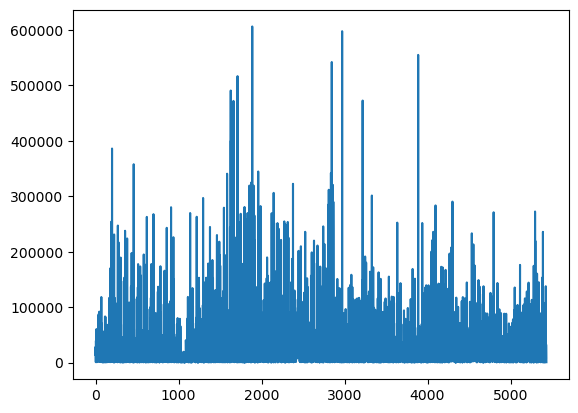

In [189]:
# TRAIN-TEST SPLIT
#There is no test data. We split our train data to train-test data. 4.5 years i.e. time index 54 is the cutoff
#X.fillna(0)

X_train = X[X['time_index']<54].copy()
X_test = X[X['time_index']>=54].copy()

Y_train = X_train['amount_new_house_transactions']
Y_test = X_test['amount_new_house_transactions']
Y = X['amount_new_house_transactions']

X_train.drop('amount_new_house_transactions', axis=1, inplace=True)
X_test.drop('amount_new_house_transactions', axis=1, inplace=True)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

plt.plot(Y)
plt.show()

## SCALING INPUT FOR Neural Network and converting to PyTorch tensors

In [190]:
# SCALING THE DATA SINCE NeuralNetworks need scaled and standardised data

#scaler = StandardScaler()
#categorical_col_names = ['time_index', 'sector', 'sin_month', 'cos_month'] #for city_search - keyword_code and source_code too
#categorical_col_train = X_train[categorical_col_names]
#categorical_col_test = X_test[categorical_col_names]

#X_numeric_train = X_train.drop(columns=categorical_col_names)
#X_numeric_test = X_test.drop(categorical_col_names, axis=1)

# SCALING ONLY NUMERIC COLUMNS
#X_numeric_scaled_train = scaler.fit_transform(X_numeric_train)
#X_numeric_scaled_test = scaler.transform(X_numeric_test)

# Convert scaled array back to DataFrame with proper column names and original index
#X_numeric_scaled_train = pd.DataFrame(X_numeric_scaled_train, columns=X_numeric_train.columns, index=X_numeric_train.index)
#X_numeric_scaled_test = pd.DataFrame(X_numeric_scaled_test, columns=X_numeric_test.columns, index=X_numeric_test.index)

#print(X_numeric_scaled_train.shape, X_numeric_train.shape, categorical_col_train.shape)

# Concatenate categorical and scaled numerical columns
#X_train = pd.concat([categorical_col_train, X_numeric_scaled_train], axis=1)
#X_test = pd.concat([categorical_col_test, X_numeric_scaled_test], axis=1)

#X_train = torch.tensor(X_train, dtype=torch.float32)
#Y_train = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)
#X_test = torch.tensor(X_test, dtype=torch.float32)
#Y_test = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)

#X.head()


In [202]:
# Using pipeline and preprocessing for SCALING THE DATA SINCE NeuralNetworks need scaled and standardised data

numerical_categorical_cols = ['time_index', 'sector', 'sin_month', 'cos_month'] #for city_search - keyword_code and source_code too
X_numeric_train = X_train.drop(columns=numerical_categorical_cols)
numeric_cols = X_numeric_train.columns

# Numeric pipeline: impute missing values, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, numerical_categorical_cols)
    ]
)

# Fitting on train, transforming on both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(Y_train.shape)
target_scaler = StandardScaler()
Y_train_scaled = target_scaler.fit_transform(Y_train.to_numpy().reshape(-1, 1))
Y_test_scaled = target_scaler.fit_transform(Y_test.to_numpy().reshape(-1, 1))

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_processed, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train_scaled, dtype=torch.float32).view(-1, 1)  # regression
Y_test_tensor  = torch.tensor(Y_test_scaled, dtype=torch.float32).view(-1, 1)

(4274,)


## Defining the PyTorch Neural Network

In [206]:
class PriceForecaster(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model_NN = PriceForecaster(input_dim=X_train_tensor.shape[1])

## TRAINING THE MODEL

In [207]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_NN.parameters(), lr=1e-4)

num_epochs = 500

for epoch in range(num_epochs):
    model_NN.train()
    optimizer.zero_grad()
    Y_predict = model_NN(X_train_tensor)
    loss = criterion(Y_predict, Y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model_NN.eval()
        test_loss = criterion(model_NN(X_test_tensor), Y_test_tensor).item()
        print(f"Epoch {epoch}: Train Loss={loss.item():.4f}, Test Loss={test_loss:.4f}")

Epoch 0: Train Loss=1.1910, Test Loss=1.1029
Epoch 100: Train Loss=0.1852, Test Loss=0.4743
Epoch 200: Train Loss=0.0490, Test Loss=0.3049
Epoch 300: Train Loss=0.0194, Test Loss=0.2493
Epoch 400: Train Loss=0.0085, Test Loss=0.2267


In [208]:
# After completing training
model_NN.eval()                             # Set model to evaluation mode
with torch.no_grad():                    # Disable gradients for prediction
    Y_predict = model_NN(X_test_tensor)  
    
#rmse = np.sqrt(mean_squared_error(Y_test_tensor, Y_predict))
#mae = mean_absolute_error(Y_test_tensor, Y_predict)
#r2 = r2_score(Y_test_tensor, Y_predict)
mape = abs((abs(Y_test_tensor - Y_predict) / Y_test_tensor).mean() * 100)
print('MAPE: ',mape,'%')

MAPE:  tensor(13.5069) %


Neural Net Perceptron (left joins, train-test cutoff 4.5 years) 
MAPE  : 13.51


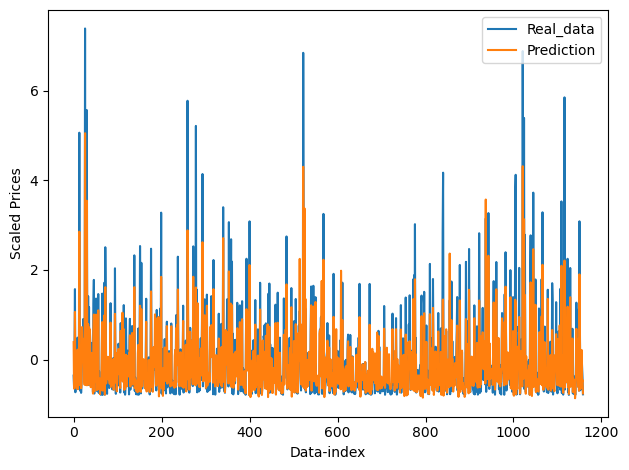

In [209]:
print("Neural Net Perceptron (left joins, train-test cutoff 4.5 years) ")
print(f"MAPE  : {mape:.2f}")

x_axis_indices = np.arange(len(Y_test_tensor))
#plt.scatter(x_axis_indices, Y_test_tensor[:20000], label='Real_data',s=10)
#plt.scatter(x_axis_indices, Y_predict[:20000], label='Prediction',s=10)
plt.plot(Y_test_tensor[:20000], label='Real_data')
plt.plot(Y_predict[:20000], label='Prediction')
plt.xlabel("Data-index")
plt.ylabel("Scaled Prices")
plt.tight_layout()
plt.legend()
plt.savefig("predictions_vs_real_left_joins_incl_city_search.png")

- Neural Net Perceptron (left joins, including city_search data) MAPE  : 13.51 %